# 05 — Per-sensor track crossings for PIXELAV (experiment "B")

Notebook 04 extracted the full shower cascade. **This notebook turns that truth into the input a
high-fidelity silicon-pixel simulation needs.** That simulation is **PIXELAV** (M. Swartz, the
charge-transport model behind the CMS pixel templates); it wants one record per **charged-track
crossing of a silicon sensor** — the entry point, the direction, the momentum and the particle
type, in that sensor's local frame.

**How we get those crossings — read the silicon out as a tracker.** A calorimeter records energy
deposits; it cannot tell you a track's *momentum*. So for this purpose we run the simulation once
more with the ECal silicon configured as a Geant4 **tracker** (one steering line, §2). A tracker
sensitive detector produces one `SimTrackerHit` per sensor crossing carrying exactly what PIXELAV
needs — **position, momentum and path length** — with no reconstruction on our part.

> The original approach built the same crossings from the *calorimeter* step-energy truth
> (`CaloHitContribution`s) by time-ordering the steps, which works but has no per-step momentum.
> It is preserved, with all its plots and learnings, in
> [`05b_calo_step_method.ipynb`](05b_calo_step_method.ipynb), and remains the fallback when only a
> calorimeter readout is available. This notebook uses the tracker readout throughout.

**Units:** momenta / energies in GeV, positions in mm.

## 1. What PIXELAV consumes — and why energy deposits are *not* it

PIXELAV is **not** an energy-deposit consumer. Given a charged track's geometry and kinematics it
**generates its own ionization internally** (Bichsel dE/dx + Landau straggling + delta rays), then
drifts, diffuses and traps the electron–hole pairs through the sensor's electric and magnetic
fields to produce the induced pixel signal. So we feed it **track segments**, never the Geant4
energy deposits. It works in two stages:

| Stage | What it is | Who provides it |
|-------|------------|-----------------|
| **A** — sensor / field model | E-field, weighting potential, thickness, bias, B-field, pitch | hand-authored **per sensor**, external to our sim (see notebook 06 §6) |
| **B** — per-track event input | **one record per charged-track crossing of a sensor** | **this notebook** |

A Stage-B record, in the sensor's **local** frame (`u` across the pitch, `v` along cylinder-z, `w`
the sensor-normal / depth axis):
- the **local entry point** `(u, v)` on the entry face;
- the **direction cosines** `cot α = p_u/p_w`, `cot β = p_v/p_w`;
- the **momentum magnitude** `|p|` (sets the βγ / dE/dx regime — a MIP vs a soft electron);
- the **particle type**.

Whole-track endpoints from notebook 04 are not enough: an `MCParticle`'s vertex/endpoint bracket
its *entire* trajectory, possibly several sensors apart, whereas PIXELAV works **one sensor at a
time**. The per-crossing truth is what we surface here.

## 2. The method — read the silicon out as a Geant4 tracker

The calorimeter readout writes `CaloHitContribution`s with a step's position and energy but **no
momentum** (the EDM4hep schema has no momentum field). To get the real per-crossing momentum we
map the ECal silicon to Geant4's tracker sensitive action — one line in
[`sim/run_sim_trackermom.py`](../sim/run_sim_trackermom.py):

```python
SIM.action.mapActions['ECalBarrel'] = 'Geant4TrackerWeightedAction'
```

A tracker SD combines the steps of one sensor crossing into a single **`SimTrackerHit`** carrying
`position`, **`momentum`**, `pathLength`, `eDep`, `time` and a link to the producing `MCParticle`.
That *is* one PIXELAV crossing record — directly, with no time-ordering reconstruction. Same gun,
physics list and random seed (424242) as the calorimeter cascade, so the shower is identical; only
the Si readout differs.

Run it on EAF (Key4hep sourced; `ddsim` needs `lib_hack` on `LD_LIBRARY_PATH`, handbook §6.3):

```bash
export LD_LIBRARY_PATH=$HOME/lib_hack:$LD_LIBRARY_PATH
ddsim --compactFile SiD_TestBeam.xml --steeringFile ../sim/run_sim_trackermom.py --numberOfEvents 1
python ../analysis/extract_trackermom.py     # -> models/trackermom_*.npz (per-crossing momentum)
python ../analysis/pixelav_converter.py      # -> models/pixelav_segments_* (auto-selects Variant C)
```

`pixelav_converter.build_segments_C` turns each `SimTrackerHit` into one crossing record. Let us
load them.

In [1]:
import os, sys, json
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
sys.path.insert(0, os.path.abspath('../analysis'))
import pixelav_converter as pc

def _find(name):
    for base in ['../models', 'models', os.path.join(os.environ.get('CALOMAPS_HOME', '..'), 'models')]:
        p = os.path.join(base, name)
        if os.path.exists(p): return p
    return os.path.join('../models', name)

dT = np.load(_find('trackermom_gamma50_1evt.npz'), allow_pickle=True)
segs, stats = pc.build_segments_C(dT)                  # one record per SimTrackerHit crossing
print(f'{len(segs)} per-sensor crossings from {len(dT["thx"])} tracker hits; {stats}')

# unpack the payload into arrays
p_GeV  = np.array([s['p_GeV']    for s in segs])
eu     = np.array([s['entry_u']  for s in segs])       # mm, local across-pitch
ev     = np.array([s['entry_v']  for s in segs])       # mm, local cylinder-z
cota   = np.array([s['cot_alpha'] for s in segs])
cotb   = np.array([s['cot_beta']  for s in segs])
layer  = np.array([s['layer_id'] for s in segs])
pdg    = np.array([s['pdg']      for s in segs])
depthw = np.array([s['depth_w_mm'] for s in segs])
trk    = np.array([s['track_id'] for s in segs])
print(f'example record: {segs[0]}')

3217 per-sensor crossings from 3241 tracker hits; {'neutral_hits_skipped': 24, 'n_tracker_hits': 3241}
example record: {'track_id': 1, 'layer_id': 8, 'pdg': 11, 'p_GeV': 46.899292318330126, 'entry_u': 0.00016671580662463162, 'entry_v': -4.556476577411556e-05, 'cot_alpha': 0.00011181959257310972, 'cot_beta': -3.7477857425849126e-05, 'flipped': 1, 'sensor_normal_phi': 1.5707963267948966, 'depth_w_mm': 1297.0099999999998, 'energy_dep_GeV': 0.0001066317199729383, 'n_steps': 1, 'time_ns': 4.326893329620361, 'variant': 'C', 'flags': 'tracker_hit'}


## 3. The local frame and two geometry choices

The ECal is a 12-sided Si–W barrel with its axis along z; each flat face's outward normal points
radially. For a crossing we rotate into the local frame where **`w`** is the sensor normal (depth),
**`u`** is across the pitch and **`v`** is the cylinder-z axis — the frame PIXELAV expects. Two
choices in that mapping are easy to get subtly wrong, and the data settles both:

- **Where is the face?** The dodecagon could present a face *centre* or a *vertex* at +y. The hit
  azimuth peaks sharply at **90°**, so the +y beam strikes a face *centre* (`FACE_PHI0 = 0`).
  Getting this wrong by 15° would throw the local entry point off by `r·sin15° ≈ 300 mm`.
- **What labels a layer — radius or depth?** The sensors are **flat**, so a layer sits at constant
  **depth** `w` (perpendicular face distance), *not* constant radius `r=√(x²+y²)`. Assigning by
  radius mislabels wide-shower crossings into the wrong layer; assigning by **depth** keeps every
  crossing within a sub-mm of its geometric layer centre. The right panel shows both.

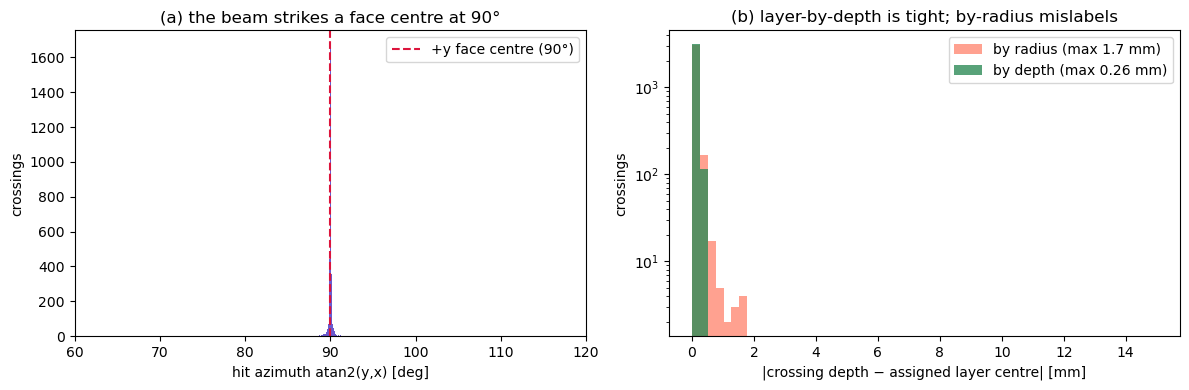

In [2]:
thx, thy = dT['thx'], dT['thy']
phin = pc.face_phi(thx, thy)
centers = pc.si_layer_centers()
wdep = thx*np.cos(phin) + thy*np.sin(phin)             # depth (face-normal projection)
r    = np.sqrt(thx**2 + thy**2)
lay_depth  = np.argmin(np.abs(wdep[:, None] - centers[None, :]), axis=1)
lay_radius = np.argmin(np.abs(r[:, None]    - centers[None, :]), axis=1)
resid_depth  = np.abs(wdep - centers[lay_depth])
resid_radius = np.abs(r    - centers[lay_radius])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(np.degrees(np.arctan2(thy, thx)), bins=120, color='slateblue')
ax[0].axvline(90, color='crimson', ls='--', label='+y face centre (90°)')
ax[0].set_xlabel('hit azimuth atan2(y,x) [deg]'); ax[0].set_ylabel('crossings'); ax[0].set_xlim(60, 120)
ax[0].set_title('(a) the beam strikes a face centre at 90°'); ax[0].legend()
ax[1].hist(resid_radius, bins=np.linspace(0, 15, 60), alpha=0.6, color='tomato', label=f'by radius (max {resid_radius.max():.1f} mm)')
ax[1].hist(resid_depth,  bins=np.linspace(0, 15, 60), alpha=0.8, color='seagreen', label=f'by depth (max {resid_depth.max():.2f} mm)')
ax[1].set_xlabel('|crossing depth − assigned layer centre| [mm]'); ax[1].set_ylabel('crossings')
ax[1].set_title('(b) layer-by-depth is tight; by-radius mislabels'); ax[1].legend(); ax[1].set_yscale('log')
plt.tight_layout(); plt.show()

## 4. The payload — the per-sensor PIXELAV records

One record per crossing, everything Stage B needs. Reading the four panels:

- **(a) Local entry points** — where on the sensor face each crossing enters, pooled over all 30
  layers, measured from the detector axis (`(0,0)` = the +y beam axis). The ±tens-of-mm spread is
  the shower's transverse footprint, not the 100 µm pitch (PIXELAV samples the sub-pixel impact
  itself; see notebook 06).
- **(b) Direction vs momentum** — `cot α` split into momentum bands: hard tracks pile up at
  `cot α ≈ 0` (perpendicular), soft tracks fan out — the expected EM-shower behaviour.
- **(c) Crossing-momentum spectrum** — now the **real** per-crossing momentum (§5). It rises to a
  peak around tens of MeV: the soft sub-MeV particles born in the dense tungsten are absorbed
  before reaching silicon, so only those energetic enough to reach (and cross more of) the sensors
  register.
- **(d) Crossings per layer** — the longitudinal shower profile in track crossings: rising from the
  front, a maximum near shower-max, then the dying tail.

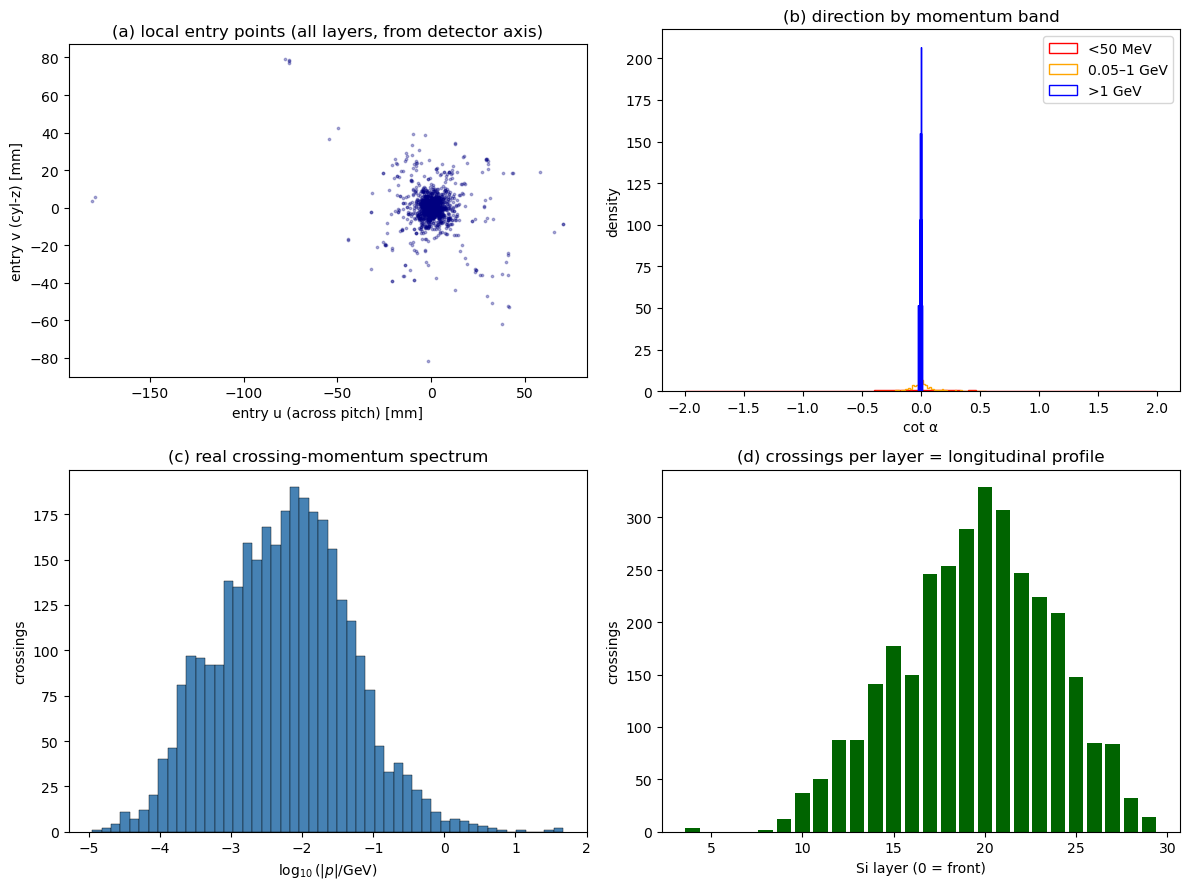

In [3]:
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
# (a) local entry points
ax[0,0].scatter(eu, ev, s=3, alpha=0.3, color='navy')
ax[0,0].set_xlabel('entry u (across pitch) [mm]'); ax[0,0].set_ylabel('entry v (cyl-z) [mm]')
ax[0,0].set_title('(a) local entry points (all layers, from detector axis)'); ax[0,0].set_aspect('equal')
# (b) cot alpha in momentum bands
for lo, hi, c, lab in [(0,0.05,'red','<50 MeV'),(0.05,1,'orange','0.05–1 GeV'),(1,1e9,'blue','>1 GeV')]:
    m = (p_GeV>=lo)&(p_GeV<hi)&np.isfinite(cota)&(np.abs(cota)<2)
    if m.sum(): ax[0,1].hist(cota[m], bins=60, histtype='step', color=c, label=lab, density=True)
ax[0,1].set_xlabel('cot α'); ax[0,1].set_ylabel('density'); ax[0,1].set_title('(b) direction by momentum band'); ax[0,1].legend()
# (c) momentum spectrum
pp = p_GeV[p_GeV>0]
ax[1,0].hist(np.log10(pp), bins=50, color='steelblue', edgecolor='k', lw=0.3)
ax[1,0].set_xlabel(r'$\log_{10}(|p|/\mathrm{GeV})$'); ax[1,0].set_ylabel('crossings'); ax[1,0].set_title('(c) real crossing-momentum spectrum')
# (d) crossings per layer
L = np.arange(layer.min(), layer.max()+1)
ax[1,1].bar(L, [np.sum(layer==l) for l in L], color='darkgreen')
ax[1,1].set_xlabel('Si layer (0 = front)'); ax[1,1].set_ylabel('crossings'); ax[1,1].set_title('(d) crossings per layer = longitudinal profile')
plt.tight_layout(); plt.show()

## 5. The momentum, validated

Because the tracker hit carries the **true Geant4 momentum at the crossing**, the deck no longer
reuses a particle's production momentum for its deep crossings (the old method's main limitation).
Four checks:
- **(a)** the per-crossing momentum spectrum (real) peaks at a few MeV — the soft EM shower;
- **(b)** each crossing's momentum vs its producing particle's *production* momentum sits **on or
  below the diagonal** — energy can only be lost between birth and a crossing, never gained;
- **(c)** the median momentum **falls with depth** as the shower softens;
- **(d)** the leading conversion electron, crossing-by-crossing, loses momentum **monotonically**
  from tens of GeV as it radiates through the stack.

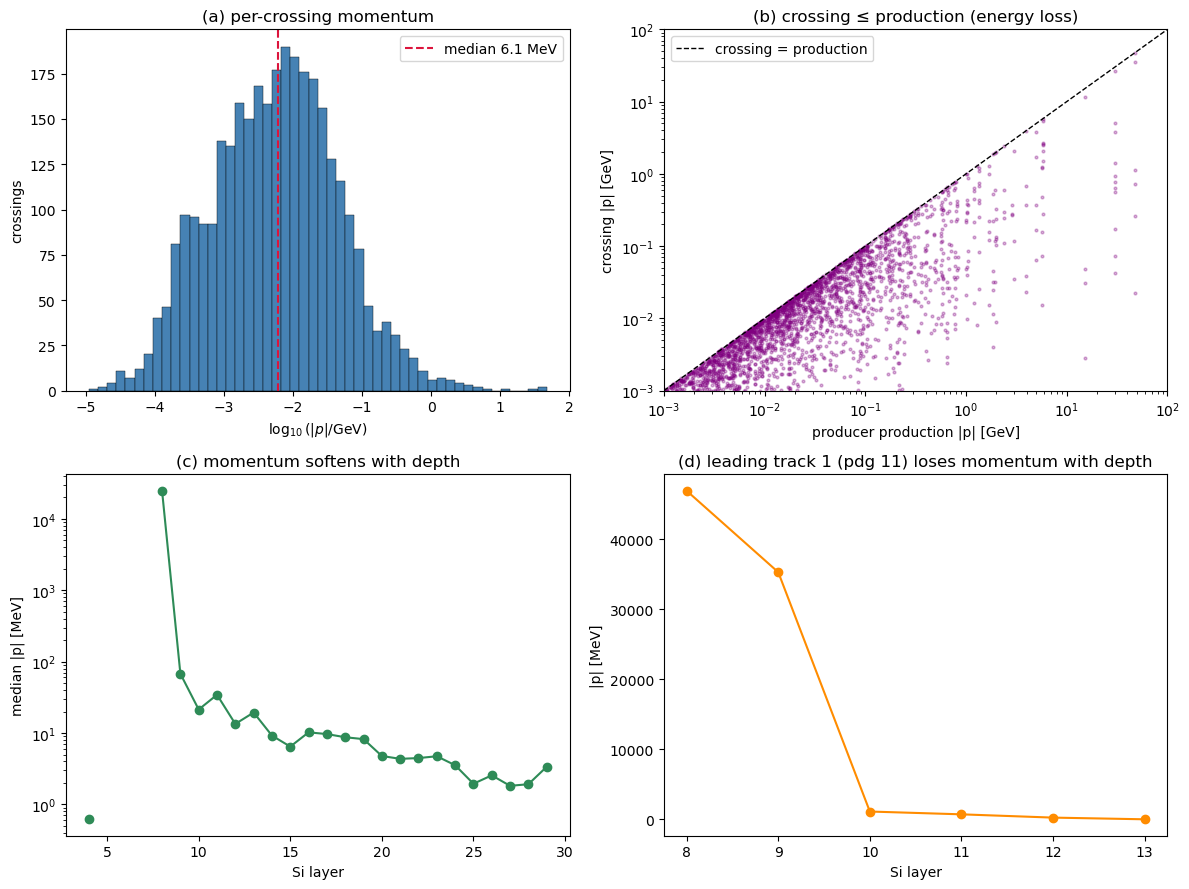

In [4]:
pprod = np.sqrt(dT['px'][trk]**2 + dT['py'][trk]**2 + dT['pz'][trk]**2)
fig, ax = plt.subplots(2, 2, figsize=(12, 9))
m = p_GeV > 0
ax[0,0].hist(np.log10(p_GeV[m]), bins=50, color='steelblue', edgecolor='k', lw=0.3)
ax[0,0].axvline(np.log10(np.median(p_GeV[m])), color='crimson', ls='--', label=f'median {np.median(p_GeV[m])*1e3:.1f} MeV')
ax[0,0].set_xlabel(r'$\log_{10}(|p|/\mathrm{GeV})$'); ax[0,0].set_ylabel('crossings'); ax[0,0].set_title('(a) per-crossing momentum'); ax[0,0].legend()
good = (p_GeV>0)&(pprod>0)
ax[0,1].scatter(pprod[good], p_GeV[good], s=4, alpha=0.3, color='purple')
lim=[1e-3,1e2]; ax[0,1].plot(lim,lim,'k--',lw=1,label='crossing = production')
ax[0,1].set_xscale('log'); ax[0,1].set_yscale('log'); ax[0,1].set_xlim(lim); ax[0,1].set_ylim(lim)
ax[0,1].set_xlabel('producer production |p| [GeV]'); ax[0,1].set_ylabel('crossing |p| [GeV]'); ax[0,1].set_title('(b) crossing ≤ production (energy loss)'); ax[0,1].legend()
Lp = np.arange(layer.min(), layer.max()+1)
medp = [np.median(p_GeV[layer==l]) if np.any(layer==l) else np.nan for l in Lp]
ax[1,0].plot(Lp, np.array(medp)*1e3, 'o-', color='seagreen'); ax[1,0].set_yscale('log')
ax[1,0].set_xlabel('Si layer'); ax[1,0].set_ylabel('median |p| [MeV]'); ax[1,0].set_title('(c) momentum softens with depth')
cand=[(t,(trk==t).sum(),pprod[trk==t][0]) for t in np.unique(trk)]
lead=max((c for c in cand if c[1]>=3), key=lambda c:c[2])[0]
sel=trk==lead; o=np.argsort(layer[sel])
ax[1,1].plot(layer[sel][o], p_GeV[sel][o]*1e3, 'o-', color='darkorange')
ax[1,1].set_xlabel('Si layer'); ax[1,1].set_ylabel('|p| [MeV]'); ax[1,1].set_title(f'(d) leading track {lead} (pdg {dT["pdg"][lead]}) loses momentum with depth')
plt.tight_layout(); plt.show()

## 6. Geometry validation

Two consistency checks on the records. **(a)** each crossing's recorded depth minus its assigned
layer mid-plane is sub-millimetre — every crossing really sits inside the 320 µm sensor it was
labelled with. **(b)** the direction steepness `|cot| = √(cot α² + cot β²)` versus momentum
collapses to `|cot|≈0` (perpendicular) at high `|p|` and fans out at low `|p|` — a crossing's angle
is set by its momentum, as it must be. The printout reports the inward/outward split (backscattered
tracks heading to smaller radius), which the momentum-direction handles with the correct sign.

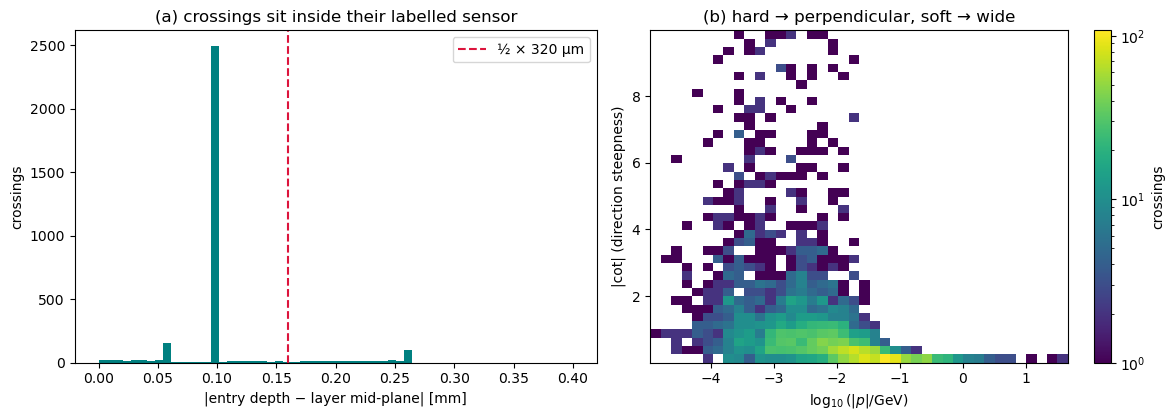

inward-going (toward smaller radius): 645;  outward-going: 2572  — momentum direction gives each the correct cot sign


In [5]:
cen = centers[layer]
resid = np.abs(depthw - cen)
cotmag = np.sqrt(cota**2 + cotb**2)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
ax[0].hist(resid, bins=np.linspace(0, 0.4, 60), color='teal'); ax[0].axvline(0.16, color='crimson', ls='--', label='½ × 320 µm')
ax[0].set_xlabel('|entry depth − layer mid-plane| [mm]'); ax[0].set_ylabel('crossings'); ax[0].set_title('(a) crossings sit inside their labelled sensor'); ax[0].legend()
mm = (p_GeV>0)&np.isfinite(cotmag)&(cotmag<10)
hb = ax[1].hist2d(np.log10(p_GeV[mm]), cotmag[mm], bins=[40,40], cmap='viridis', norm=LogNorm())
fig.colorbar(hb[3], ax=ax[1], label='crossings')
ax[1].set_xlabel(r'$\log_{10}(|p|/\mathrm{GeV})$'); ax[1].set_ylabel('|cot| (direction steepness)'); ax[1].set_title('(b) hard → perpendicular, soft → wide')
plt.tight_layout(); plt.show()
nin = int(np.sum(np.array([s['flipped'] for s in segs])==0)); nout = len(segs)-nin
print(f'inward-going (toward smaller radius): {nin};  outward-going: {nout}  — momentum direction gives each the correct cot sign')

## Summary & what's next

- The per-sensor PIXELAV input is produced programmatically from the simulation: the ECal silicon
  is read out as a Geant4 **tracker**, so each `SimTrackerHit` is one crossing carrying the **real**
  entry point, direction and **momentum** — `pixelav_converter` (Variant C) reshapes them into
  per-crossing records with `cot α`/`cot β`, `|p|` and particle type.
- The reconstruction choices are validated against the data: the +y face at 90°, layers labelled by
  depth, the real momentum (on/below the production diagonal, softening with depth), and the
  expected hard-perpendicular / soft-wide angular behaviour.
- The original **calorimeter step-energy method** (time-ordered `CaloHitContribution`s, no per-step
  momentum) is preserved with all its plots in
  [`05b_calo_step_method.ipynb`](05b_calo_step_method.ipynb) — the fallback when only a calorimeter
  readout is available.
- **Next:** [notebook 06](06_pixelav_clusters.ipynb) runs PIXELAV on these records and studies the
  resulting pixel charge clusters and the downstream observables (charge, cluster size, position
  resolution).